<a href="https://colab.research.google.com/github/Heng1222/Ohsumed_classification/blob/acc-time-plot/task1_pytorch_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torchinfo

In [4]:
from huggingface_hub import HfApi, login, create_repo
import os
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
import torch
import time
import torch.nn as nn
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from peft import PeftModel
from torchinfo import summary
from huggingface_hub import HfApi, login, create_repo, hf_hub_download, notebook_login

# 1. 定義分類模型 (維持原樣)
class RobertaClassifier(nn.Module):
    def __init__(self, model_path_or_name, num_labels=23, freeze_backbone=True, useLoRA=False):
        super(RobertaClassifier, self).__init__()
        self.roberta = RobertaModel.from_pretrained(model_path_or_name)
        if useLoRA:
            LoRA_folder = "maxbeettww/roberta-MeSH-lora"
            self.roberta = PeftModel.from_pretrained(self.roberta, LoRA_folder)
        if freeze_backbone:
            for param in self.roberta.parameters():
                param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(768, 1024), nn.LayerNorm(1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )
    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

# 2. 資料集處理 (維持原樣)
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {'input_ids': self.encodings['input_ids'][idx], 'attention_mask': self.encodings['attention_mask'][idx], 'labels': self.labels[idx]}

# 3. 訓練與評估主程式 (新增紀錄與最終上傳功能)
def run_experiment(model_name_or_path, train_df, test_df, num_epochs=30, useLoRA=False, folder_name="default_model_name"):
    api = HfApi()
    username = api.whoami()['name']
    repo_id = f"{username}/{folder_name}"
    create_repo(repo_id, exist_ok=True)
    uploaded_checkpoints = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaClassifier(model_name_or_path, num_labels=23, useLoRA=useLoRA)

    # 自動續傳邏輯
    resume_epoch = 0
    try:
        repo_files = api.list_repo_tree(repo_id)
        ckpt_folders = [f.path for f in repo_files if "checkpoint-" in f.path]
        if ckpt_folders:
            resume_epoch = max([int(f.split('-')[-1]) for f in ckpt_folders])
            uploaded_checkpoints = sorted(ckpt_folders, key=lambda x: int(x.split('-')[-1]))
            ckpt_file = hf_hub_download(repo_id=repo_id, filename="pytorch_model.bin", subfolder=f"checkpoint-{resume_epoch}")
            model.load_state_dict(torch.load(ckpt_file, map_location=device))
            print(f"續傳成功：從 Epoch {resume_epoch+1} 開始")
    except: pass

    model.to(device)

    train_data, val_data = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
    train_loader = DataLoader(TextDataset(train_data['title'].tolist(), train_data['label'].tolist(), tokenizer), batch_size=32, shuffle=True)
    val_loader = DataLoader(TextDataset(val_data['title'].tolist(), val_data['label'].tolist(), tokenizer), batch_size=32)
    test_loader = DataLoader(TextDataset(test_df['title'].tolist(), test_df['label'].tolist(), tokenizer), batch_size=32)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    # --- [關鍵：初始化紀錄清單] ---
    history = []
    total_time = 0

    for epoch in range(resume_epoch, num_epochs):
        epoch_start = time.perf_counter()

        # Training
        model.train()
        train_preds, train_labels = [], []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                logits = model(ids, mask)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        epoch_end = time.perf_counter()
        duration = epoch_end - epoch_start
        total_time += duration

        t_acc = accuracy_score(train_labels, train_preds)
        v_acc = accuracy_score(val_labels, val_preds)

        # --- [儲存當前 Epoch 數據] ---
        history.append({
            'epoch': epoch + 1,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'epoch_duration_sec': duration,
            'cumulative_time_sec': total_time
        })

        # 每 5 Epoch 上傳 Checkpoint (維持最近 2 個)
        curr_count = epoch + 1
        if curr_count % 1 == 0:
            ckpt_dir = "./ckpt_tmp"
            os.makedirs(ckpt_dir, exist_ok=True)
            torch.save(model.state_dict(), f"{ckpt_dir}/pytorch_model.bin")
            remote_f = f"checkpoint-{curr_count}"
            api.upload_folder(folder_path=ckpt_dir, repo_id=repo_id, path_in_repo=remote_f)
            uploaded_checkpoints.append(remote_f)
            if len(uploaded_checkpoints) > 2:
                old = uploaded_checkpoints.pop(0)
                try: api.delete_folder(path_in_repo=old, repo_id=repo_id)
                except: pass

        print(f"Epoch {curr_count} - Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}, Time: {duration:.2f}s")

    # --- [關鍵：訓練結束後的最終上傳] ---
    print("\n--- 訓練完成，正在上傳最終模型與日誌 ---")

    # 1. 儲存最終模型
    final_dir = "./final_model"
    os.makedirs(final_dir, exist_ok=True)
    torch.save(model.state_dict(), f"{final_dir}/pytorch_model.bin")
    tokenizer.save_pretrained(final_dir)
    api.upload_folder(folder_path=final_dir, repo_id=repo_id, path_in_repo="final_model")

    # 2. 儲存訓練日誌 CSV
    log_df = pd.DataFrame(history)
    log_df.to_csv("training_history.csv", index=False)
    api.upload_file(path_or_fileobj="training_history.csv", path_in_repo="training_history.csv", repo_id=repo_id)

    print(f"所有資料已成功同步至 Hugging Face Repo: {repo_id}")
    return val_labels, val_preds

# 執行區
if __name__ == "__main__":
    notebook_login()
    # (資料讀取部分維持不變...)
    url = 'https://github.com/Heng1222/Ohsumed_classification/blob/main/classification_data/ohsumed_dataset.csv?raw=true'
    full_df = pd.read_csv(url)[['label', 'title']]
    unique_labels = sorted(full_df['label'].unique())
    label_to_id = {l: i for i, l in enumerate(unique_labels)}
    full_df['label'] = full_df['label'].map(label_to_id)
    min_size = full_df['label'].value_counts().min()
    full_df = full_df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min_size, random_state=42)).reset_index(drop=True)
    train_df, test_df = train_test_split(full_df, test_size=0.1, random_state=42, stratify=full_df['label'])

    # 實驗 1: 使用 原版RoBERTa
    print("Running Experiment with Base RoBERTa...")
    run_experiment('roberta-base', train_df, test_df, folder_name = "RoBERTa_based")

    # 實驗 2: 使用 MLM
    # print("Running Experiment with Custom RoBERTa...")
    # run_experiment('maxbeettww/roberta-ohsumed-mlm', train_df, test_df, folder_name = "RoBERTa_MLM")

    # 實驗 3: 使用 LoRA
    # print("Running Experiment with RoBERTa + LoRA...")
    # run_experiment('roberta-base', train_df, test_df, useLoRA = True, folder_name = "RoBERTa_LoRA")

/tmp/ipython-input-3472335147.py:172: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_df = full_df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min_size, random_state=42)).reset_index(drop=True)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


checkpoint-5/pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

續傳成功：從 Epoch 6 開始


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_model/pytorch_model.bin:   7%|6         | 33.6MB /  504MB            

所有資料已成功同步至 Hugging Face Repo: Alyssalai/RoBERTa_based


UnboundLocalError: cannot access local variable 'val_labels' where it is not associated with a value

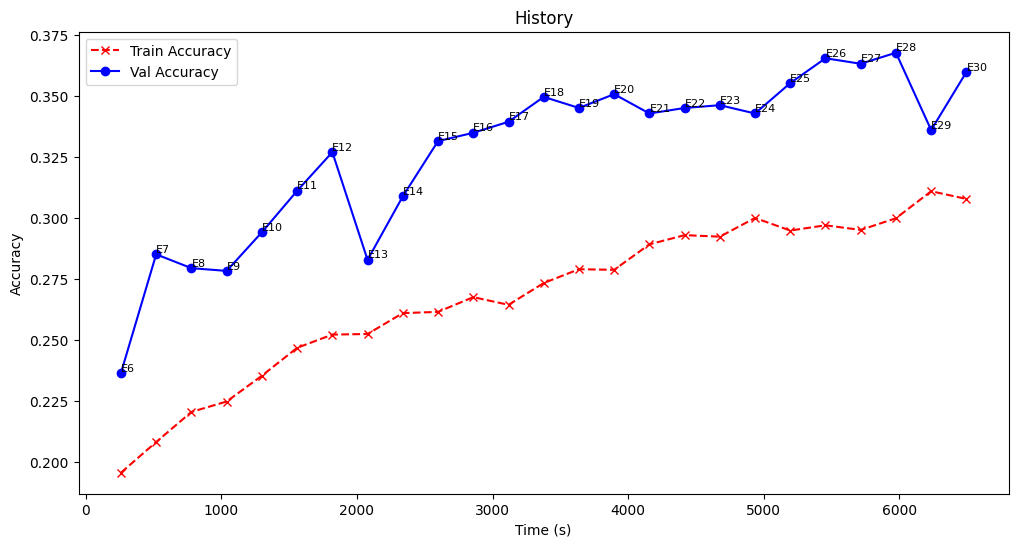

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# 指向有成功跑完 30 epoch 的專案名稱
repo_id = "Alyssalai/RoBERTa_Final_Project"

try:
    # 從 Hub 下載歷史紀錄
    log_path = hf_hub_download(repo_id=repo_id, filename="training_history.csv")
    df = pd.read_csv(log_path)

    # 繪圖
    plt.figure(figsize=(12, 6))
    plt.plot(df['cumulative_time_sec'], df['train_acc'], 'r--x', label='Train Accuracy')
    plt.plot(df['cumulative_time_sec'], df['val_acc'], 'b-o', label='Val Accuracy')

    # 標註 Epoch (E1, E2...)
    for i, row in df.iterrows():
        plt.text(row['cumulative_time_sec'], row['val_acc'], f"E{int(row['epoch'])}",
                 fontsize=8, verticalalignment='bottom')

    plt.title(f'History')
    plt.xlabel('Time (s)')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
except Exception as e:
    print(f"讀取失敗：{e}")